<a href="https://colab.research.google.com/github/Rogerio-mack/sync_nirs/blob/main/Sync_by_coherence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sync Fourier/Welch Coherence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Get data

In [2]:
path = 'https://github.com/Rogerio-mack/sync_nirs/raw/refs/heads/main/'

df = pd.read_csv(path + 'fnirs_synthetic_10ch_data.csv')
df_communities_ground_truth = pd.read_csv(path + 'fnirs_synthetic_10ch_groundtruth.csv')

display(df.head())
display(df_communities_ground_truth.head())

,subj,task,time,SD0,SD1,SD2,SD3,SD4,SD5,SD6,SD7,SD8,SD9
0,1,A,0.0,0.173850,1.439444,0.453721,0.090090,1.880227,0.249911,0.535990,-0.450369,-0.041995,-0.275822
1,1,A,0.1,-0.026403,1.541374,0.158524,-0.289698,1.961922,-0.246487,-0.145328,0.798297,-0.379475,1.719652
2,1,A,0.2,0.270659,1.575110,0.282585,-0.075958,1.894357,0.124004,-0.544744,0.764648,-0.493876,-0.623913
3,1,A,0.3,0.598986,1.050629,0.469599,-0.102499,1.882283,0.024815,0.332205,-0.937506,-0.035908,0.963907
4,1,A,0.4,0.005898,1.765079,0.145542,0.413182,1.477168,0.384076,1.069364,-0.846965,0.274944,-0.122699


,subj,task,channel,community
0,1,A,SD7,3
1,1,A,SD8,4
2,1,A,SD9,5
3,1,A,SD0,1
4,1,A,SD1,1


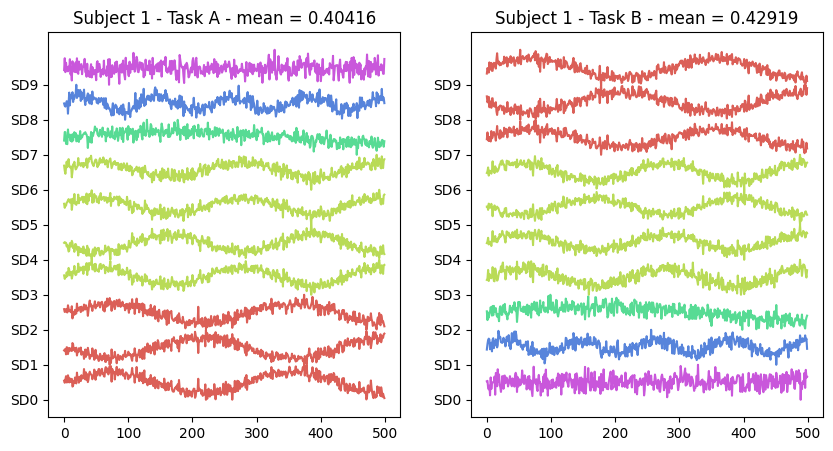

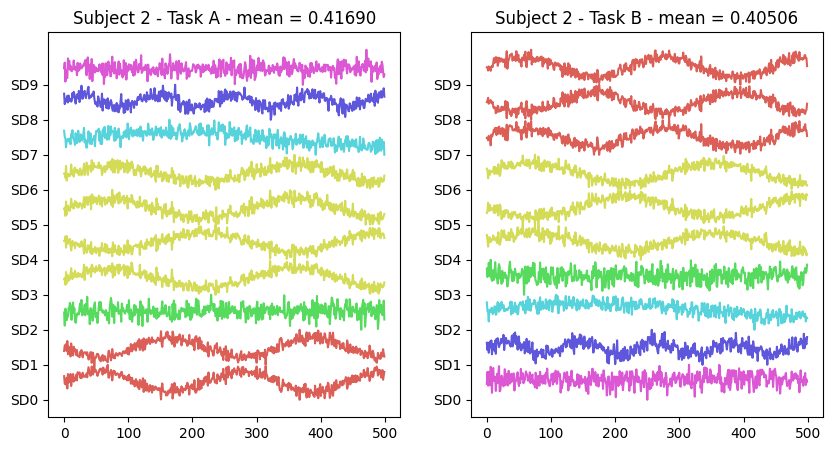

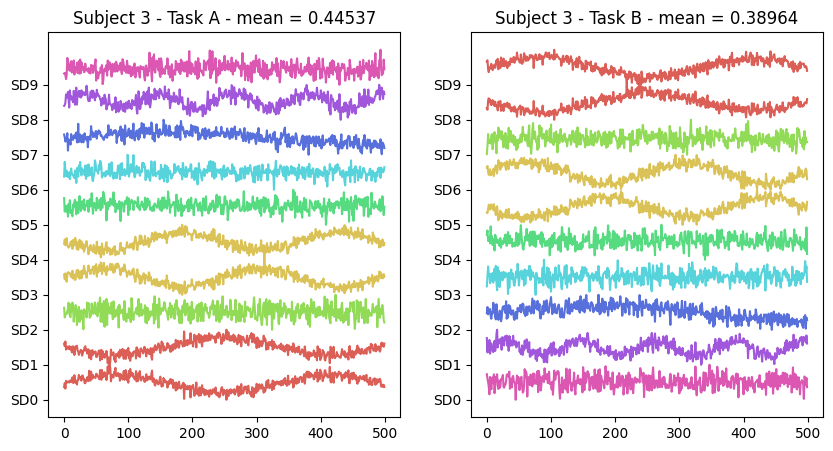

In [3]:
from sklearn.preprocessing import minmax_scale

nr_communities = len(df_communities_ground_truth.community.unique())

cmap = sns.color_palette("hls", nr_communities)

for s in df.subj.unique():
  plt.figure(figsize=(10,5))
  task_nr = 1
  for t in df.task.unique():

    sel_subj_task = (df_communities_ground_truth.subj == s) & (df_communities_ground_truth.task == t)
    df_communities_subj_task = df_communities_ground_truth[sel_subj_task]
    nr_communities = len(df_communities_subj_task.community.unique())
    cmap = sns.color_palette("hls", nr_communities)

    df_temp = df[(df.task == t) & (df.subj == s)]
    df_temp = df_temp.drop(columns=['subj','time','task'])

    for coluna in range(len(df_temp.columns)):
      community_idx = df_communities_subj_task[ df_communities_subj_task.channel == df_temp.columns[coluna] ].community.values[0]
      plt.subplot(1,len(df.task.unique()),task_nr)
      plt.plot(minmax_scale(df_temp.iloc[:,coluna])+coluna, color=cmap[community_idx-1])

      plt.yticks(ticks=range(0,df_temp.shape[1]), labels=df_temp.columns[0:df_temp.shape[1]])
      plt.title(f'Subject {s} - Task {t} - mean = {df_temp.mean().mean():.5f}')
    task_nr = task_nr + 1
  plt.show()


# `compute_coherence_matrix`

In [4]:
!pip install pycwt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.0/755.0 kB 12.8 MB/s eta 0:00:00


In [5]:
!pip install bctpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 3.8 MB/s eta 0:00:00


In [6]:
from scipy.signal import coherence

def compute_coherence_matrix(signals, fs=10.0):

    n = len(signals)

    matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(i, n): # Compute only upper triangle (including diagonal)
            f, Cxy = coherence(signals[i], signals[j], fs)
            matrix[i,j] = np.mean(Cxy)
            if i != j: # Ensure symmetry by mirroring to the lower triangle
                matrix[j,i] = matrix[i,j]

    adj_matrix = matrix

    return adj_matrix

# Single subj and task

In [7]:
def select_subj_task(df, subj, task):
  s = subj
  t = task
  sel_df = (df.subj == s) & (df.task == t)

  channel_names = [ col for col in df.columns if col.startswith("S") ]
  signals = np.matrix( df[ sel_df ][ channel_names ] ).T

  return signals, channel_names

signals, channel_names = select_subj_task(df, 1, "A")

adj_matrix = compute_coherence_matrix(signals, fs=10.0)
signals.shape, adj_matrix.shape

((10, 500), (10, 10))

## Plot matrix

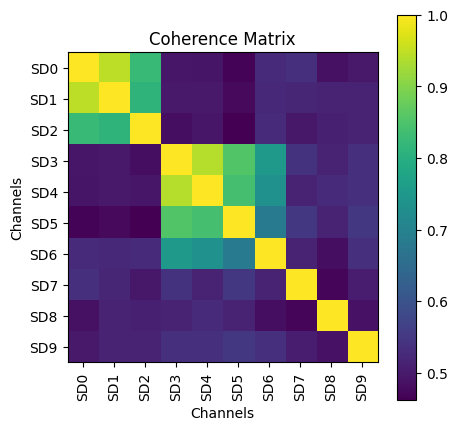

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(adj_matrix, cmap='viridis')
plt.colorbar()

plt.title('Coherence Matrix')
plt.xlabel('Channels')
plt.ylabel('Channels')
plt.xticks(range(len(channel_names)), channel_names, rotation=90)
plt.yticks(range(len(channel_names)), channel_names)

plt.show()





In [9]:
print(f"Is adj_matrix symmetric: {np.array_equal(adj_matrix, adj_matrix.T)}")

Is adj_matrix symmetric: True


## `get_communities`

In [10]:
def get_communities(channel_names, adj_matrix, density = 0.25, gamma_louvain = 1.0, all_metrics = True):
  # density = Limiar proporcional mantendo as 25% conexões mais fortes

  def get_metrics(n_null_models=20):

    # Coeficiente de Agrupamento Médio (Clustering Coefficient)
    # Requer normalização dos pesos da matriz para [0, 1]
    W_norm = bct.weight_conversion(W_thresh, 'normalize')
    clustering_coefs = bct.clustering_coef_wu(W_norm)
    C_empirical = np.mean(clustering_coefs)

    # Comprimento Médio do Caminho Característico (Characteristic Path Length - L)
    # Transforma pesos em distâncias inversas (conexão mais forte = menor distância)
    distance_matrix = bct.distance_wei(bct.weight_conversion(W_thresh, 'lengths'))[0]

    # CORREÇÃO PARA LIDAR COM VALORES inf de distance_matrix
    # Encontra o maior valor finito na matriz
    max_val = np.max(distance_matrix [np.isfinite(distance_matrix)])

    # Substitui o 'inf' por esse valor máximo (ou max_val + 1)
    distance_matrix[np.isinf(distance_matrix)] = max_val

    # Ignora distâncias infinitas se houver nós desconexos
    L_empirical = bct.charpath(distance_matrix)[0]

    # -------------------------------------------------------------
    # Small-Worldness (Sigma = (C / C_null) / (L / L_null))
    # -------------------------------------------------------------
    if False:
      C_nulls, L_nulls = [], []
      for _ in range(n_null_models):
          # Gera grafo nulo preservando a distribuição de graus e força dos nós
          W_null, _ = bct.null_model_und_sign(W_thresh)

          # Clustering do grafo nulo
          W_null_norm = bct.weight_conversion(W_null, 'normalize')
          C_nulls.append(np.mean(bct.clustering_coef_wu(W_null_norm)))

          # Path length do grafo nulo
          dist_null = bct.distance_wei(bct.weight_conversion(W_null, 'lengths'))[0]
          L_nulls.append(bct.charpath(dist_null)[0])

      gamma = C_empirical / np.mean(C_nulls)   # Razão de agrupamento
      lambda_ = L_empirical / np.mean(L_nulls) # Razão de caminho
      small_worldness_sigma = gamma / lambda_  # Sigma > 1 indica propriedade small-world

    metrics = {
        'Nodal_Strength': nodal_strength,
        'Nodal_Degree': nodal_degree,
        'Modularity_Q': modularity_Q,
        'Communities': communities,
        'Characteristic_Path_Length_L': L_empirical,
        'Clustering_Coefficient_C': C_empirical,
    #    'Small_Worldness_Sigma': small_worldness_sigma
    }

    return metrics

  # ==========================================
  # 1. Carregar Dados
  # ==========================================
  import bct # Brain Connectivity Toolbox
  from scipy.spatial.distance import squareform
  from scipy.cluster.hierarchy import linkage, leaves_list

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  np.fill_diagonal(W, 0) # Zera diagonal

  W_thresh = bct.threshold_proportional(W, density, copy=True)
  A_bin = (W_thresh > 0).astype(float)

  # -------------------------------------------------------------
  # Métricas Nodais (Locais)
  # -------------------------------------------------------------
  # Grau (Degree) ou Força Nodal (Strength para matrizes ponderadas)
  nodal_strength = bct.strengths_und(W_thresh)
  nodal_degree = bct.degrees_und(A_bin)

  communities, modularity_Q = bct.community_louvain(W_thresh, gamma=gamma_louvain)

  # Métricas nodais e modulares
  if all_metrics:
    metrics = get_metrics()
  else:
    metrics = {}

  data_communities = pd.DataFrame({'channel': channel_names, 'communities': communities,
                       'nodal_strength': nodal_strength,
                       'nodal_degree': nodal_degree}).sort_values('communities')

  return data_communities, W_thresh, A_bin, modularity_Q, metrics



## density = 0.25, gamma_louvain = 1.0

In [12]:
density = 0.25; gamma_louvain = 1.0

In [14]:
signals, channel_names = select_subj_task(df, 1, "A")
adj_matrix = compute_coherence_matrix(signals, fs=10.0)

df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

print("\n--- RESULTADOS TOPOLÓGICOS ---")
print(f"Modularidade (Q): {modularity_Q:.3f}")
display(df_communities)


--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.424


,channel,communities,nodal_strength,nodal_degree
0,SD0,1,1.774349,2.0
1,SD1,1,1.758447,2.0
2,SD2,1,1.638633,2.0
3,SD3,2,2.543948,3.0
4,SD4,2,2.515559,3.0
5,SD5,2,3.478771,5.0
6,SD6,2,2.168052,3.0
7,SD7,2,0.549922,1.0
9,SD9,2,0.549468,1.0
8,SD8,3,0.000000,0.0


In [15]:
for key, value in metrics.items():
  print(f"{key}: {value}")

Nodal_Strength: [1.7743491  1.75844737 1.63863315 2.54394782 2.51555862 3.47877128
 2.16805232 0.54992231 0.         0.54946812]
Nodal_Degree: [2. 2. 2. 3. 3. 5. 3. 1. 0. 1.]
Modularity_Q: 0.4236464131244388
Communities: [1 1 1 2 2 2 2 2 3 2]
Characteristic_Path_Length_L: 3.0033464780649424
Clustering_Coefficient_C: 0.5503877669336625


### Compare

In [17]:
sel_ground_truth  = (df_communities_ground_truth.subj == 1) & (df_communities_ground_truth.task == "A")

In [18]:
compare_communities = df_communities[['channel','communities']].merge(df_communities_ground_truth[sel_ground_truth][['channel','community']], on='channel')

compare_communities['is_correct'] = compare_communities['communities'] == compare_communities['community']
display(compare_communities)

print(f'Accuracy: {compare_communities.is_correct.sum()/len(compare_communities):.2f}')

,channel,communities,community,is_correct
0,SD0,1,1,True
1,SD1,1,1,True
2,SD2,1,1,True
3,SD3,2,2,True
4,SD4,2,2,True
5,SD5,2,2,True
6,SD6,2,2,True
7,SD7,2,3,False
8,SD9,2,5,False
9,SD8,3,4,False


Accuracy: 0.70


## density = 0.15, gamma_louvain = 1.0

In [19]:
density = 0.15; gamma_louvain = 1.0

In [21]:
signals, channel_names = select_subj_task(df, 1, "A")
adj_matrix = compute_coherence_matrix(signals, fs=10.0)

df_communities, W_thresh, A_bin, modularity_Q, metrics = get_communities(channel_names, adj_matrix, density = density, gamma_louvain = gamma_louvain)

print("\n--- RESULTADOS TOPOLÓGICOS ---")
print(f"Modularidade (Q): {modularity_Q:.3f}")
display(df_communities)


--- RESULTADOS TOPOLÓGICOS ---
Modularidade (Q): 0.491


,channel,communities,nodal_strength,nodal_degree
0,SD0,1,1.774349,2.0
1,SD1,1,1.758447,2.0
2,SD2,1,1.638633,2.0
3,SD3,2,2.543948,3.0
4,SD4,2,1.780927,2.0
5,SD5,2,1.696290,2.0
6,SD6,2,0.750330,1.0
7,SD7,3,0.000000,0.0
8,SD8,4,0.000000,0.0
9,SD9,5,0.000000,0.0


### Compare

In [22]:
compare_communities = df_communities[['channel','communities']].merge(df_communities_ground_truth[sel_ground_truth][['channel','community']], on='channel')

compare_communities['is_correct'] = compare_communities['communities'] == compare_communities['community']
display(compare_communities)

print(f'Accuracy: {compare_communities.is_correct.sum()/len(compare_communities):.2f}')

,channel,communities,community,is_correct
0,SD0,1,1,True
1,SD1,1,1,True
2,SD2,1,1,True
3,SD3,2,2,True
4,SD4,2,2,True
5,SD5,2,2,True
6,SD6,2,2,True
7,SD7,3,3,True
8,SD8,4,4,True
9,SD9,5,5,True


Accuracy: 1.00


In [23]:
for key, value in metrics.items():
  print(f"{key}: {value}")

Nodal_Strength: [1.7743491  1.75844737 1.63863315 2.54394782 1.78092681 1.69629019
 0.75032987 0.         0.         0.        ]
Nodal_Degree: [2. 2. 2. 3. 2. 2. 1. 0. 0. 0.]
Modularity_Q: 0.4910252173664444
Communities: [1 1 1 2 2 2 2 3 4 5]
Characteristic_Path_Length_L: 2.2947290553585593
Clustering_Coefficient_C: 0.48853819290512457


## `get_blocks`

In [24]:
def get_blocks(communities, adj_reordered):

  # communities = data.communities.values
  order = np.argsort(communities)

  sorted_communities_values = communities[order]

  # print("Communities sorted by index (defining blocks):")
  # print(sorted_communities_values)
  # print("\nExtracting blocks from adj_reordered:")

  current_community = -1
  start_idx = 0
  blocks_info = []

  for i, comm_id in enumerate(sorted_communities_values):
      if comm_id != current_community:
          if current_community != -1:
              end_idx = i
              blocks_info.append((current_community, start_idx, end_idx))
          current_community = comm_id
          start_idx = i
      # print(f"Channel {i} belongs to community {comm_id}")
      # print(blocks_info)

  blocks_info.append((current_community, start_idx, len(sorted_communities_values)))

  # for comm_id, start_idx, end_idx in blocks_info:
  #    print(f"\n--- Community Group G{{comm_id}} (Indices {start_idx}:{end_idx}) ---")
  #    block_matrix = adj_reordered[start_idx:end_idx, start_idx:end_idx]
  #    print(block_matrix)

  adj_matrix_blocks = np.ones_like(adj_reordered)

  for comm_id, start_idx, end_idx in blocks_info:
      adj_matrix_blocks[start_idx:end_idx, start_idx:end_idx] = adj_reordered[start_idx:end_idx, start_idx:end_idx]



  return adj_matrix_blocks, blocks_info

# adj_matrix_blocks, blocks_info = get_blocks(data.communities.values, adj_reordered)

# plt.imshow(adj_matrix_blocks, cmap='viridis')
# plt.show()

## `plot_adj_matrix_communities`

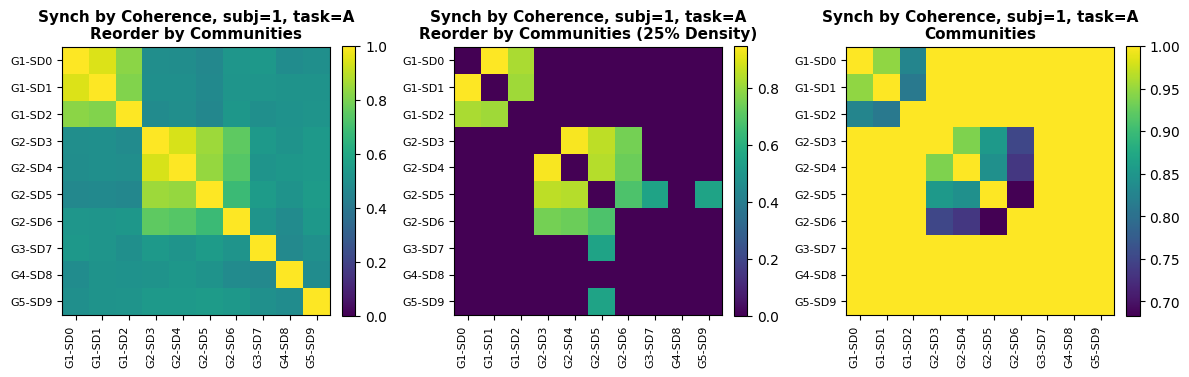

In [28]:
def plot_adj_matrix_communities(channel_names, adj_matrix, communities, title):

  # channel_names = [ col for col in df.columns if col.startswith("S") ]
  # metric = 'Coherence'

  if not isinstance(communities, np.ndarray):
    raise ValueError("A variável 'communities' deve ser um np.array()")

  import bct # Brain Connectivity Toolbox

  n_channels = len(channel_names)

  # ==========================================
  # 3. Teoria dos Grafos (BCT)
  # ==========================================
  W = adj_matrix.copy()
  np.fill_diagonal(W, 0) # Zera diagonal

  # Limiar proporcional mantendo as 25% conexões mais fortes
  density = 0.25
  W_thresh = bct.threshold_proportional(W, density, copy=True)

  order = np.argsort(communities)

  # Reordenar todas as matrizes e rótulos
  adj_reordered = adj_matrix[np.ix_(order, order)]
  # p_reordered = p_matrix[np.ix_(order, order)]
  W_thresh_reordered = W_thresh[np.ix_(order, order)]
  # W_sig_reordered = A_bin[np.ix_(order, order)]
  labels_reordered = [channel_names[idx] for idx in order]
  groups = [communities[idx] for idx in order]
  labels_reordered = [f'G{l2}-{l1}' for l1, l2 in zip(labels_reordered, groups)]

  adj_matrix_blocks, blocks_info = get_blocks(communities, adj_reordered)

  # ==========================================
  # 5. Visualização Comparativa
  # ==========================================

  fig, axes = plt.subplots(1, 3, figsize=(12, 4))
  # axes = np.array(axes).flatten()

  # Painel 1: Coerência Reordenada
  im1 = axes[0].imshow(adj_reordered, cmap='viridis', vmin=0, vmax=1)
  # sns.heatmap(adj_reordered, ax=axes[0], cmap='viridis', vmin=0, vmax=1)
  axes[0].set_title(title + f"\nReorder by Communities",fontsize=11,weight='bold')
  axes[0].set_xticks(range(n_channels))
  axes[0].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[0].set_yticks(range(n_channels))
  # axes[0].set_yticklabels(labels_reordered, rotation=0)
  axes[0].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im2 = axes[1].imshow(W_thresh_reordered, cmap='viridis')
  axes[1].set_title(title + f"\nReorder by Communities ({int(density*100)}% Density)",fontsize=11,weight='bold')
  axes[1].set_xticks(range(n_channels))
  axes[1].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[1].set_yticks(range(n_channels))
  axes[1].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

  # Matriz Limiarizada com Blocos Modulares
  im3 = axes[2].imshow(adj_matrix_blocks, cmap='viridis')
  axes[2].set_title(title + f"\nCommunities",fontsize=11,weight='bold')
  axes[2].set_xticks(range(n_channels))
  axes[2].set_xticklabels(labels_reordered, rotation=90, ha='right',fontsize=8)
  axes[2].set_yticks(range(n_channels))
  axes[2].set_yticklabels(labels_reordered,fontsize=8)
  fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

  plt.tight_layout()
  plt.show()

  return adj_reordered, W_thresh_reordered, labels_reordered

metric = 'Coherence'
subj = 1
task = "A"

channel_names = [ col for col in df.columns if col.startswith("S") ]
title = f"Synch by {metric}, subj={subj}, task={task}"
adj_reordered, W_thresh_reordered, labels_reordered = plot_adj_matrix_communities(channel_names, adj_matrix, df_communities.communities.values, title)

## `plot_grafo`

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_grafo(W, communities, nodal_strength, channel_names, title):
  # 1. Carregar Grafo a partir da matriz limiarizada (W_sig)
  G = nx.from_numpy_array(W)
  mapping = {i: name for i, name in enumerate(channel_names)}
  G = nx.relabel_nodes(G, mapping)

  pos = nx.spring_layout(G, seed=42, k=0.7)

  # 2. Extrair Pesos das Arestas
  edges = G.edges(data=True)
  weights = np.array([d['weight'] for u, v, d in edges])

  # 3. Criar Dicionário com Rótulos Numéricos das Arestas (ex: "0.98")
  edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges}

  # 4. Configurar Nós
  max_str = np.max(nodal_strength) if np.max(nodal_strength) > 0 else 1.0
  node_sizes = 600 + 1400 * (nodal_strength / max_str)
  unique_comms = np.unique(communities)
  cmap_nodes = plt.get_cmap('tab10', len(unique_comms))
  node_colors = [cmap_nodes(np.where(unique_comms == comm)[0][0]) for comm in communities]

  plt.figure(figsize=(9, 7))

  # Desenhar Nós e Rótulos dos Canais
  nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=1.5)
  nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

  # Desenhar Arestas (com espessura e gradiente de cor variando com o peso)
  edge_widths = weights * 4.5
  nx.draw_networkx_edges(
      G, pos,
      width=edge_widths,
      edge_color=weights,
      edge_cmap=plt.cm.Blues,
      edge_vmin=0.0,
      edge_vmax=1.0,
      alpha=0.85
  )

  # Desenhar os Valores Numéricos nas Arestas
  nx.draw_networkx_edge_labels(
      G, pos,
      edge_labels=edge_labels,
      font_size=8,
      font_color='darkblue',
      bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
  )

  # Adicionar Barra de Cores (Colorbar) para a Força das Arestas
  sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=0.0, vmax=1.0))
  sm.set_array([])
  cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
  cbar.set_label('Connection Strengths', rotation=270, labelpad=15)

  # Adicionar legenda de módulos/comunidades
  for comm_id in unique_comms:
      plt.scatter([], [], color=cmap_nodes(np.where(unique_comms == comm_id)[0][0]),
                  label=f'Comm = {comm_id}', s=100, edgecolors='black')

  plt.legend(scatterpoints=1, frameon=True, loc='upper left', title="Communities", fontsize=9)

  plt.title(title, fontsize=12, pad=15, weight='bold')
  plt.axis('off')
  plt.tight_layout()
  plt.show()

  return

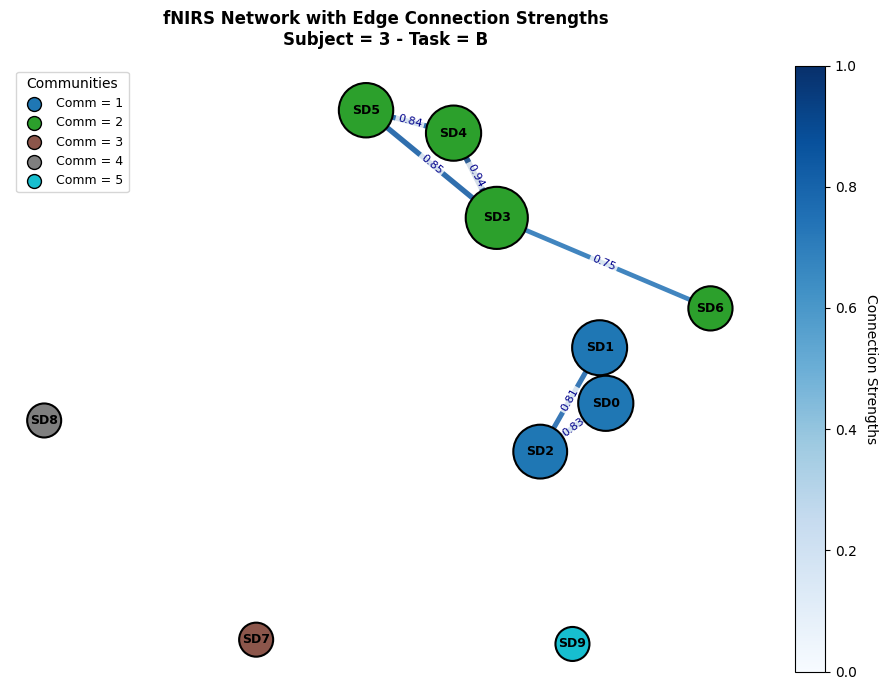

In [30]:
communities = df_communities.communities.values
nodal_strength = df_communities.nodal_strength.values
channel_names = df_communities.channel.values

title = f"fNIRS Network with Edge Connection Strengths\nSubject = {s} - Task = {t}"
plot_grafo(W_thresh, communities, nodal_strength, channel_names, title)

# Louvain com Consenso Modular

In [33]:
# -------------------------------------------------------------
# 1. Pipeline de Consenso para um dado Gamma (ex: gamma = 1.2)
# -------------------------------------------------------------
def compute_modularity(adj_matrix, ci, gamma=1.0):
    """
    Calcula o valor exato da modularidade Q para uma partição conhecida `ci`.
    Compatível com grafos ponderados não-direcionados.
    """
    ci = np.array(ci)
    k = np.sum(adj_matrix, axis=1)  # Grau/força de cada nó
    m2 = np.sum(k)                  # 2m: soma total dos pesos

    if m2 == 0:
        return 0.0

    # Matriz delta de Kronecker: delta[i, j] = 1 se ci[i] == ci[j], senão 0
    delta = np.equal.outer(ci, ci).astype(float)

    # Modelo nulo de Newman-Girvan: (k_i * k_j) / (2m)
    null_model = gamma * np.outer(k, k) / m2

    # Q = (1 / 2m) * sum((A_ij - gamma * null_ij) * delta_ij)
    Q = np.sum((adj_matrix - null_model) * delta) / m2
    return float(Q)

def run_consensus_louvain(adj_matrix, gamma=1.0, n_iter=100, tau=0.4):

    n_nodes = adj_matrix.shape[0]

    # 1. Matriz 2D para armazenar todas as partições: shape (n_nodes, n_iter)
    all_partitions = np.zeros((n_nodes, n_iter), dtype=int)

    for it in range(n_iter):
        ci, _ = bct.community_louvain(adj_matrix, gamma=gamma)
        all_partitions[:, it] = ci

    # 2. Matriz de concordância absoluta (número de co-ocorrências)
    agreement_matrix = bct.agreement(all_partitions)

    # 3. Limiar tau escalado para o número de iterações
    # Se tau=0.4 e n_iter=100, corta co-ocorrências abaixo de 40
    tau_scaled = tau * n_iter

    # bct.consensus_und retorna apenas o vetor 1D com os rótulos de módulo
    consensus_ci = bct.consensus_und(
        agreement_matrix,
        tau=tau_scaled,
        reps=n_iter
    )

    # 4. Avalia Q na matriz original limiarizada
    q_consensus = compute_modularity(adj_matrix, consensus_ci, gamma=gamma)

    return consensus_ci, q_consensus, agreement_matrix


import bct # Brain Connectivity Toolbox
density = 0.25
W = adj_matrix.copy()
np.fill_diagonal(W, 0) # Zera diagonal

W_thresh = bct.threshold_proportional(W, density, copy=True)

# -------------------------------------------------------------
# 2. Varredura de Resolução (Gamma Tuning)
# -------------------------------------------------------------
gamma_values = np.linspace(0.5, 2.5, 21)
num_communities = []
modularity_scores = []
cis = []

for g in gamma_values:
    ci, q, _ = run_consensus_louvain(W_thresh, gamma=g, n_iter=50, tau=0.35)
    num_communities.append(len(np.unique(ci)))
    modularity_scores.append(q)
    cis.append(ci)

# Exibição dos resultados da varredura
for g, k, q, ci in zip(gamma_values, num_communities, modularity_scores, cis):
    print(f"Gamma: {g:.2f} | Módulos encontrados: {k:2d} | Q: {q:.4f} | ci: {ci}")

Gamma: 0.50 | Módulos encontrados:  3 | Q: 0.7118 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.60 | Módulos encontrados:  3 | Q: 0.6542 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.70 | Módulos encontrados:  3 | Q: 0.5966 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.80 | Módulos encontrados:  3 | Q: 0.5389 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 0.90 | Módulos encontrados:  3 | Q: 0.4813 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.00 | Módulos encontrados:  3 | Q: 0.4236 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.10 | Módulos encontrados:  3 | Q: 0.3660 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.20 | Módulos encontrados:  3 | Q: 0.3084 | ci: [1. 1. 1. 2. 2. 2. 2. 2. 3. 2.]
Gamma: 1.30 | Módulos encontrados:  4 | Q: 0.2689 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.40 | Módulos encontrados:  4 | Q: 0.2342 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.50 | Módulos encontrados:  4 | Q: 0.1996 | ci: [1. 1. 1. 2. 2. 3. 2. 3. 4. 3.]
Gamma: 1.60 | Módulos encontrado